# Segmentación semántica de imágenes aéreas con redes profundas caso de estudio Yalí Antioquia Colombia
Este cuaderno presenta una implementación sencilla en PyTorch de una Red Totalmente Convolucional para la segmentación semántica de imágenes aéreas. Más concretamente, nuestro objetivo es realizar automáticamente la interpretación de escenas de imágenes tomadas desde un avión o un satélite clasificando cada píxel en varias clases de cobertura del suelo.

Como demostración, vamos a utilizar la arquitectura SegNet para segmentar imágenes aéreas en este caso no sobre las ciudades de Vaihingen y Potsdam sino con la Ortofoto y la rasterización de vectores de un municipio de Antioquia Colombia llamado Yalí. Las imágenes proceden del conjunto de datos de etiquetado semántico 2D YALI_dataset. Entrenaremos una red para segmentar vías, edificios, bosques y fondo.

Este trabajo es una implementación de PyTorch de la línea base presentada en "Más allá del RGB: Very High Resolution Urban Remote Sensing With Multimodal Deep Networks", Nicolas Audebert, Bertrand Le Saux y Sébastien Lefèvre, ISPRS Journal, 2018.

## Requisitos
Este cuaderno requiere algunas bibliotecas útiles, por ejemplo,torch`, `scikit-image`, `numpy` and `matplotlib . Puedes instalar todo usando .torchscikit-imagenumpymatplotlibpip install -r requirements.txt

Se espera que funcione en GPU, por lo que deberías usarlo en combinación con CUDA/cuDNN. Probablemente esto se pueda hacer funcionar en CPU, pero ten en cuenta que:torch
* Tienes que eliminar todas las llamadas a lo largo de este cuaderno,torch.Tensor.cuda()
* Esto será muy lento.

Una GPU "pequeña" debería ser suficiente, por ejemplo, funciona bien en un Tesla K20m de 4,7GB. Utiliza bastante RAM porque el conjunto de datos se almacena en memoria. Puedes ahorrar algo de memoria desactivando la caché que aparece abajo. 4GB deberían ser más que suficientes sin necesidad de caché.

In [1]:
# imports and stuff
import numpy as np
from skimage import io
from glob import glob
from tqdm import tqdm_notebook as tqdm
from sklearn.metrics import confusion_matrix
import random
import itertools
# Matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
# Torch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
import torch.optim.lr_scheduler
import torch.nn.init
from torch.autograd import Variable

### 1. Definición de rutas base y exploración del dataset de Yalí

En este bloque de código inicio definiendo las rutas principales que voy a utilizar para trabajar con el dataset de Yalí.

1. **Importación de `Path`:**  
   Utilizo `Path` de la librería `pathlib` para manejar rutas de archivos y carpetas de forma más ordenada y compatible entre sistemas operativos.

2. **Ruta raíz del proyecto (`ROOT`):**  
   ```python
   ROOT = Path(".").resolve()
   print("ROOT:", ROOT)


In [2]:
from pathlib import Path

# Carpeta raíz del repo (donde está este notebook)
ROOT = Path(".").resolve()
print("ROOT:", ROOT)

# Carpeta del dataset de Yalí
YALI = ROOT / "YALI_dataset/YALI_segnet/"
print("YALI existe?  ", YALI.exists())
print("Contenido de YALI_dataset:")
for p in YALI.iterdir():
    print(" -", p)


ROOT: /workspace/DeepNetsForEO
YALI existe?   True
Contenido de YALI_dataset:
 - /workspace/DeepNetsForEO/YALI_dataset/YALI_segnet/.ipynb_checkpoints
 - /workspace/DeepNetsForEO/YALI_dataset/YALI_segnet/mask
 - /workspace/DeepNetsForEO/YALI_dataset/YALI_segnet/ortho
 - /workspace/DeepNetsForEO/YALI_dataset/YALI_segnet/tiles


### 🌍 Configuración de rutas para la ortofoto, la máscara y las teselas

En este bloque de código defino las rutas clave que voy a utilizar durante todo el proceso de teselado del dataset de Yalí. La idea es dejar claramente configurados los caminos hacia la **ortofoto**, la **máscara de clases** y la **carpeta donde se guardarán los tiles**.

In [3]:
from pathlib import Path

ROOT = Path(".").resolve()
YALI = ROOT / "YALI_dataset/YALI_segnet/"

# Ajusta estos nombres a lo que tengas realmente:
ORTHO_PATH = YALI / "ortho" / "orto.tif"   # <-- CAMBIA nombre si es otro
MASK_PATH  = YALI / "mask"  / "mask_vf.tif"    # <-- CAMBIA nombre si es otro

OUT_ROOT = YALI / "tiles"        # Aquí se crearán images/ y masks/

print("ORTO :", ORTHO_PATH)
print("MASK :", MASK_PATH)
print("OUT  :", OUT_ROOT)
print("Orto existe? ", ORTHO_PATH.exists())
print("Mask existe? ", MASK_PATH.exists())

ORTO : /workspace/DeepNetsForEO/YALI_dataset/YALI_segnet/ortho/orto.tif
MASK : /workspace/DeepNetsForEO/YALI_dataset/YALI_segnet/mask/mask_vf.tif
OUT  : /workspace/DeepNetsForEO/YALI_dataset/YALI_segnet/tiles
Orto existe?  True
Mask existe?  True


In [4]:
!pip install rasterio tqdm

### 🧩 Corte de la ortofoto y la máscara en tiles

En este bloque realizo el **teselado** de la ortofoto y de la máscara de clases, es decir, las corto en pequeños parches (`tiles`) de tamaño fijo para poder usarlos después en el entrenamiento de un modelo de segmentación semántica.

🔧 **¿Qué hace este código, en pocas palabras?**

- 📂 Crea dos carpetas de salida:
  - `images/` → donde se guardan los tiles de la ortofoto.
  - `masks/` → donde se guardan los tiles de la máscara.

- ⚙️ Define el tamaño de cada tile (por ejemplo, 256×256 píxeles) y el salto entre tiles (`STRIDE`), que puede o no generar traslape.

- 🛰️ Abre la ortofoto y la máscara, verifica que:
  - tengan el mismo tamaño en píxeles,
  - estén alineadas espacialmente,
  - y tengan metadatos consistentes.

- 📏 Recorre el raster en forma de cuadrícula, y en cada posición:
  - recorta un tile de la ortofoto,
  - recorta el tile correspondiente de la máscara.

- 🧹 Opcionalmente **descarta tiles vacíos** (cuando la máscara es puro fondo), para no llenar el dataset con parches que no aportan información.

- 💾 Guarda cada par imagen–máscara como dos archivos GeoTIFF separados, con nombres tipo:
  - `yali_00001_img.tif`
  - `yali_00001_mask.tif`

✅ **Finalidad:**  
Dejar el dataset organizado en cientos o miles de pequeñas imágenes y sus máscaras alineadas, listas para alimentar una red de segmentación (por ejemplo, SegNet o U-Net), en vez de trabajar con la ortofoto completa.


In [5]:
import numpy as np
import rasterio
from rasterio.windows import Window
from tqdm import tqdm

# Crear carpetas de salida
IMG_DIR  = OUT_ROOT / "images"
MASK_DIR = OUT_ROOT / "masks"
IMG_DIR.mkdir(parents=True, exist_ok=True)
MASK_DIR.mkdir(parents=True, exist_ok=True)

print("Carpeta imágenes:", IMG_DIR)
print("Carpeta máscaras:", MASK_DIR)

# ====== PARÁMETROS DE TILE ======
TILE_SIZE = 256   # tamaño del parche (256x256). Puedes usar 512 si quieres.
STRIDE    = 256  # salto entre ventanas. Si usas 128, tendrás traslape.

SKIP_EMPTY       = True   # saltar tiles donde la máscara es todo fondo
BACKGROUND_VALUE = 0      # valor de fondo de tu máscara (ajusta si es otro)

# ====== TESelado ======
with rasterio.open(ORTHO_PATH) as src_img, rasterio.open(MASK_PATH) as src_msk:

    # 1) Comprobar que orto y máscara coinciden
    assert src_img.width  == src_msk.width,  "Ancho diferente entre orto y máscara"
    assert src_img.height == src_msk.height, "Alto diferente entre orto y máscara"
    assert src_img.transform == src_msk.transform, "Transform diferente entre orto y máscara"

    height = src_img.height
    width  = src_img.width
    print(f"Dimensiones raster: {width} x {height}")
    print(f"Bandas orto:   {src_img.count}, dtype: {src_img.dtypes[0]}")
    print(f"Bandas máscara:{src_msk.count}, dtype: {src_msk.dtypes[0]}")

    tile_id = 0

    # Rango de ventanas (solo tiles completos, sin padding)
    y_range = range(0, height - TILE_SIZE + 1, STRIDE)
    x_range = range(0, width  - TILE_SIZE + 1, STRIDE)

    for y in tqdm(y_range, desc="Filas"):
        for x in x_range:
            window = Window(x, y, TILE_SIZE, TILE_SIZE)

            # Leer orto (todas las bandas) y máscara (banda 1)
            img_tile = src_img.read(window=window)          # (bands, H, W)
            msk_tile = src_msk.read(1, window=window)       # (H, W)

            # Opción: saltar tiles que son solo fondo
            if SKIP_EMPTY and np.all(msk_tile == BACKGROUND_VALUE):
                continue

            # Metadatos para el tile de orto
            img_meta = src_img.meta.copy()
            img_meta.update({
                "height": TILE_SIZE,
                "width": TILE_SIZE,
                "transform": rasterio.windows.transform(window, src_img.transform)
            })

            # Metadatos para el tile de máscara
            msk_meta = src_msk.meta.copy()
            msk_meta.update({
                "count": 1,  # solo una banda (clases)
                "height": TILE_SIZE,
                "width": TILE_SIZE,
                "transform": rasterio.windows.transform(window, src_msk.transform)
            })

            tile_id += 1
            tile_name = f"yali_{tile_id:05d}"  # yali_00001, yali_00002, ...

            img_out_path = IMG_DIR  / f"{tile_name}_img.tif"
            msk_out_path = MASK_DIR / f"{tile_name}_mask.tif"

            # Guardar orto tile
            with rasterio.open(img_out_path, "w", **img_meta) as dst:
                dst.write(img_tile)

            # Guardar máscara tile
            with rasterio.open(msk_out_path, "w", **msk_meta) as dst:
                dst.write(msk_tile, 1)

    print(f"\nTiles generados: {tile_id}")

Carpeta imágenes: /workspace/DeepNetsForEO/YALI_dataset/YALI_segnet/tiles/images
Carpeta máscaras: /workspace/DeepNetsForEO/YALI_dataset/YALI_segnet/tiles/masks
Dimensiones raster: 23029 x 12260
Bandas orto:   4, dtype: uint8
Bandas máscara:1, dtype: uint8


Filas: 100%|████████████████████████████████████████████████████████████████████████████| 47/47 [01:48<00:00,  2.32s/it]


Tiles generados: 1801


### 👁️ Revisión visual de un tile (orto vs máscara)

En este bloque hago una **verificación visual** de que el teselado salió bien y de que cada tile de la ortofoto está correctamente alineado con su máscara de clases.

🔍 **¿Qué hace este código?**

- Selecciona un tile de la carpeta de imágenes (`images/`) y el tile correspondiente de la carpeta de máscaras (`masks/`).  
  👉 Elijo uno que no sea el primero, sino un tile “interior”, para asegurar que tenga contenido representativo.

- Carga el tile de la ortofoto:
  - Si tiene al menos 3 bandas, toma las tres primeras y las organiza como una imagen RGB para visualizarla.
  - Si solo tiene una banda, la replica tres veces para poder verla como una imagen en color (falso RGB).

- Carga el tile de la máscara de clases (una sola banda con los `class_id`).

- Muestra ambos en una figura con dos paneles:
  - 🛰️ A la izquierda: el tile de la **ortofoto**.
  - 🎭 A la derecha: el tile de la **máscara**.

✅ **Finalidad:**  
Confirmar visualmente que:
- los tiles se generaron correctamente,
- la máscara está alineada con la ortofoto,
- y las clases (edificaciones, vías, etc.) se superponen donde deberían.

Es un chequeo rápido de calidad antes de usar los tiles en el entrenamiento del modelo.


Usando tiles:
  IMG: yali_00011_img.tif
  MSK: yali_00011_mask.tif


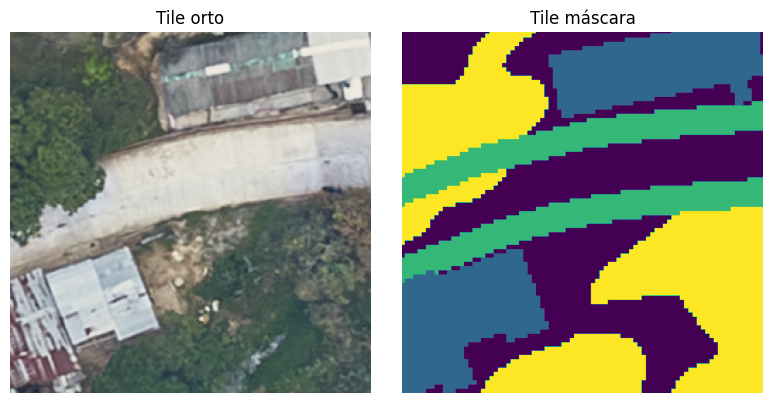

In [6]:
# Tomamos uno un poco más “interior” por si el primero tiene poco contenido
img_tile_path = sorted(IMG_DIR.glob("*.tif"))[10]
msk_tile_path = sorted(MASK_DIR.glob("*.tif"))[10]

print("Usando tiles:")
print("  IMG:", img_tile_path.name)
print("  MSK:", msk_tile_path.name)

with rasterio.open(img_tile_path) as src_img:
    img = src_img.read()  # (bands, H, W)

# Si tu orto es RGB: bandas 1,2,3
# Si es IRRG (NIR, R, G) o algo raro, luego ajustamos, por ahora probemos con las 3 primeras
if img.shape[0] >= 3:
    rgb = np.transpose(img[:3, :, :], (1, 2, 0))
else:
    # Si solo tiene 1 banda, replicamos para ver algo
    rgb = np.repeat(img[0:1, :, :], 3, axis=0)
    rgb = np.transpose(rgb, (1, 2, 0))

with rasterio.open(msk_tile_path) as src_msk:
    msk = src_msk.read(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(rgb)
ax1.set_title("Tile orto")
ax1.axis("off")

ax2.imshow(msk)
ax2.set_title("Tile máscara")
ax2.axis("off")

plt.tight_layout()
plt.show()

## Parámetros
Hay varios parámetros que se ajustaron para usar este cuaderno con los datos de Yalí. Los parámetros por defecto son adecuados para el conjunto de datos ISPRS, pero puedes cambiarlos para que funcionen con tus datos.
Ejemplos
Clasificación binaria: N_CLASSES = 2
Datos multiespectrales (por ejemplo, IRRGB): IN_CHANNELS = 4
Nueva convención de nombres de carpetas: DATA_FOLDER = MAIN_FOLDER + 'sentinel2/sentinel2_img_{}.tif'

### ⚙️ Parámetros generales del dataset y de entrenamiento

En este bloque defino los **parámetros clave** que controlan cómo se usan los tiles de Yalí dentro del modelo de segmentación semántica.

---

#### 🧩 Parámetros de los tiles e imágenes

- **Tamaño de ventana (`WINDOW_SIZE`)**:  
  Indica el tamaño de cada tile con el que voy a trabajar (por ejemplo, 256 × 256 píxeles). Coincide con el tamaño que usé al teselar.

- **Stride (`STRIDE`)**:  
  Determina cada cuánto tomo un parche para el entrenamiento. Con un valor igual al tamaño del tile se toma un parche por tile, sin traslape.

- **Canales de entrada (`IN_CHANNELS`)**:  
  Especifica cuántas bandas de la imagen usaré como entrada del modelo. Aquí uso 3 canales (RGB) aunque los GeoTIFF originales puedan tener 4 bandas.

- **Carpeta base (`FOLDER`)**:  
  Ruta raíz donde está organizado el dataset (subcarpetas, tiles, etc.), relativa al notebook.

- **Tamaño de batch (`BATCH_SIZE`)**:  
  Número de tiles que se van a procesar en cada iteración durante el entrenamiento. Se puede ajustar según la memoria disponible en la GPU o CPU.

---

#### 🏷️ Clases de la máscara y pesos

- **Lista de etiquetas (`LABELS`)**:  
  Define los nombres de las clases presentes en la máscara, en el orden de sus `class_id`.  
  Por ejemplo: fondo, edificaciones, vías, bosque.

- **Número de clases (`N_CLASSES`)**:  
  Se calcula automáticamente a partir de la longitud de la lista de etiquetas.

- **Pesos de las clases (`WEIGHTS`)**:  
  Inicialmente se asigna el mismo peso a todas las clases. Más adelante se pueden ajustar estos pesos para compensar clases poco frecuentes (balanceo de clases).

- **Uso de caché (`CACHE`)**:  
  Indica si el dataset se mantiene en memoria para acelerar el acceso a los tiles durante el entrenamiento.

---

#### 🌍 Selección del dataset y rutas a los archivos

- **Nombre del dataset (`DATASET`)**:  
  Aquí indico explícitamente que voy a trabajar con el dataset **YALI** (en lugar de Potsdam o Vaihingen, que también están contemplados como opciones).

- Para cada dataset (Potsdam, Vaihingen o Yalí), se definen:
  - La carpeta principal donde están los datos.
  - El patrón de nombres de archivo para:
    - las imágenes (tiles de ortofoto),
    - las máscaras,
    - y, en algunos casos, las máscaras erosionadas (para bordes).

- En el caso de **YALI**:
  - Se apunta a la carpeta donde se guardaron los tiles.
  - Se usan patrones de nombres tipo `yali_00001_img.tif` y `yali_00001_mask.tif` para poder acceder a cada tile por su identificador.
  - Como no hay una versión “erosionada” de las máscaras, se reutiliza la misma máscara original.

---

✅ **Finalidad:**  
Este bloque deja configurados todos los **parámetros de tamaño, clases, rutas y dataset** que el código de entrenamiento necesita para cargar correctamente los tiles de Yalí y preparar los lotes de datos que se enviarán al modelo de segmentación.


In [7]:
# Parameters
WINDOW_SIZE = (256, 256)   # tamaño de cada tile (ya están así)
STRIDE      = 256          # para entrenamiento: 1 patch por tile
IN_CHANNELS = 3            # usaremos 3 bandas (RGB) de tus GeoTIFF de 4 bandas
FOLDER      = "./YALI_dataset/"   # carpeta base de tu dataset (respecto al notebook)
BATCH_SIZE  = 10                   # puedes cambiarlo según tu GPU

# NOMBRES DE LAS CLASES EN TU MÁSCARA
# >>> AJUSTA ESTA LISTA A TUS CLASES REALES <<< 
LABELS = ["background", "buildings", "roads", "forest"]
N_CLASSES = len(LABELS)  # 4
WEIGHTS   = torch.ones(N_CLASSES)  # luego podemos cambiarlo para balancear clases
CACHE     = True                   # mantener dataset en memoria

# INDICAMOS QUE AHORA EL DATASET ES YALÍ
DATASET = 'YALI'

if DATASET == 'Potsdam':
    MAIN_FOLDER   = FOLDER + 'Potsdam/'
    DATA_FOLDER   = MAIN_FOLDER + '2_Ortho_RGB/top_potsdam_{}_RGB.tif'
    LABEL_FOLDER  = MAIN_FOLDER + '5_Labels_for_participants/top_potsdam_{}_label.tif'
    ERODED_FOLDER = MAIN_FOLDER + '5_Labels_for_participants_no_Boundary/top_potsdam_{}_label_noBoundary.tif'

elif DATASET == 'Vaihingen':
    MAIN_FOLDER   = FOLDER + 'Vaihingen/'
    DATA_FOLDER   = MAIN_FOLDER + 'top/top_mosaic_09cm_area{}.tif'
    LABEL_FOLDER  = MAIN_FOLDER + 'gts_for_participants/top_mosaic_09cm_area{}.tif'
    ERODED_FOLDER = MAIN_FOLDER + 'gts_eroded_for_participants/top_mosaic_09cm_area{}_noBoundary.tif'

elif DATASET == 'YALI':
    # Aquí apuntamos a la carpeta donde pusiste los tiles
    MAIN_FOLDER   = FOLDER + 'YALI_SEGNET/'
    
    # Patrón para leer cada tile por ID: 1, 2, 3, ... -> yali_00001_img.tif, etc.
    DATA_FOLDER   = MAIN_FOLDER + 'tiles/images/yali_{:05d}_img.tif'
    LABEL_FOLDER  = MAIN_FOLDER + 'tiles/masks/yali_{:05d}_mask.tif'
    
    # No tienes máscaras erosionadas: usamos la misma máscara normal
    ERODED_FOLDER = LABEL_FOLDER


IMG : YALI_dataset/YALI_SEGNET/tiles/images/yali_00011_img.tif
MASK: YALI_dataset/YALI_SEGNET/tiles/masks/yali_00011_mask.tif
Shape img: (256, 256, 4)


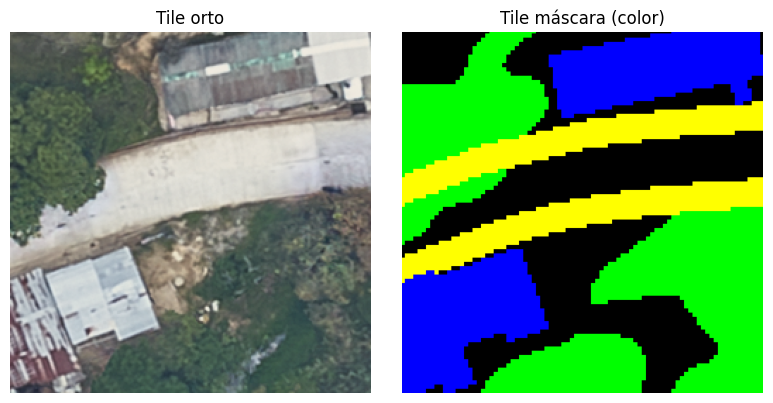

Ground truth numérica tiene shape: (256, 256)
Valores únicos en esta máscara: [0 1 2 3]


In [8]:
# ===== PALETA DE COLORES PARA YALÍ =====
# IDs de clase:
# 0: background
# 1: buildings
# 2: roads
# 3: forest
# (15 lo vamos a tratar como background en la visualización)

palette = {
    0: (0,   0,   0  ),  # background - negro
    1: (0,   0, 255 ),   # buildings  - azul
    2: (255, 255, 0  ),  # roads      - amarillo
    3: (0,  255, 0  ),   # forest     - verde
}

invert_palette = {v: k for k, v in palette.items()}

def convert_to_color(arr_2d, palette=palette):
    """Numeric labels (H,W) -> RGB (H,W,3) para visualización"""
    arr_3d = np.zeros((arr_2d.shape[0], arr_2d.shape[1], 3), dtype=np.uint8)
    for c, rgb in palette.items():
        m = arr_2d == c
        arr_3d[m] = rgb
    return arr_3d

# (En tu caso NO necesitas convert_from_color porque tu máscara ya es numérica.
# Lo dejamos fuera para simplificar.)

# ===== VISUALIZAR UN TILE DE YALÍ =====

from skimage import io
import matplotlib.pyplot as plt
from pathlib import Path

# Elegimos un ID de tile que exista (ajusta si quieres otro)
tile_id = 11

img_path = Path(FOLDER) / "YALI_SEGNET" / "tiles" / "images" / f"yali_{tile_id:05d}_img.tif"
mask_path = Path(FOLDER) / "YALI_SEGNET" / "tiles" / "masks" / f"yali_{tile_id:05d}_mask.tif"

print("IMG :", img_path)
print("MASK:", mask_path)

# Cargamos la imagen del tile
img = io.imread(img_path)      # shape (H,W,C) con 4 bandas
print("Shape img:", img.shape)

# Nos quedamos con las 3 primeras bandas (RGB) para visualizar
img_rgb = img[..., :3]

# Cargamos la máscara numérica
gt = io.imread(mask_path)      # shape (H,W) con valores 0,1,2,3,15

# Para visualizar, mapeamos 15 -> 0 (background)
gt_vis = gt.copy()
gt_vis[gt_vis == 15] = 0

# Convertimos la máscara numérica a colores
gt_color = convert_to_color(gt_vis)

fig = plt.figure(figsize=(8,4))
fig.add_subplot(121)
plt.imshow(img_rgb)
plt.title("Tile orto")
plt.axis("off")

fig.add_subplot(122)
plt.imshow(gt_color)
plt.title("Tile máscara (color)")
plt.axis("off")

plt.tight_layout()
plt.show()

# También podemos ver la máscara en formato numérico
print("Ground truth numérica tiene shape:", gt.shape)
print("Valores únicos en esta máscara:", np.unique(gt))


In [41]:
# Utils

def get_random_pos(img, window_shape):
    """Extrae un patch 2D de tamaño window_shape dentro de img.

    Si la imagen es del mismo tamaño (o más pequeña) que la ventana,
    devolvemos toda la imagen completa.
    """
    w, h = window_shape
    W, H = img.shape[-2:]  # dimensiones espaciales (ancho, alto)

    # Caso tiles: la ventana es del mismo tamaño que la imagen
    if (W <= w) or (H <= h):
        return 0, W, 0, H

    # Caso general: imagen más grande que el patch
    x1 = random.randint(0, W - w)
    x2 = x1 + w
    y1 = random.randint(0, H - h)
    y2 = y1 + h
    return x1, x2, y1, y2

def CrossEntropy2d(input, target, weight=None, size_average=True):
    """ 2D version of the cross entropy loss """
    dim = input.dim()
    if dim == 2:
        return F.cross_entropy(input, target, weight, size_average)
    elif dim == 4:
        output = input.view(input.size(0),input.size(1), -1)
        output = torch.transpose(output,1,2).contiguous()
        output = output.view(-1,output.size(2))
        target = target.view(-1)
        return F.cross_entropy(output, target,weight, size_average)
    else:
        raise ValueError('Expected 2 or 4 dimensions (got {})'.format(dim))

def accuracy(input, target):
    return 100 * float(np.count_nonzero(input == target)) / target.size

def sliding_window(top, step=10, window_size=(20,20)):
    """ Slide a window_shape window across the image with a stride of step """
    for x in range(0, top.shape[0], step):
        if x + window_size[0] > top.shape[0]:
            x = top.shape[0] - window_size[0]
        for y in range(0, top.shape[1], step):
            if y + window_size[1] > top.shape[1]:
                y = top.shape[1] - window_size[1]
            yield x, y, window_size[0], window_size[1]
            
def count_sliding_window(top, step=10, window_size=(20,20)):
    """ Count the number of windows in an image """
    c = 0
    for x in range(0, top.shape[0], step):
        if x + window_size[0] > top.shape[0]:
            x = top.shape[0] - window_size[0]
        for y in range(0, top.shape[1], step):
            if y + window_size[1] > top.shape[1]:
                y = top.shape[1] - window_size[1]
            c += 1
    return c

def grouper(n, iterable):
    """ Browse an iterator by chunk of n elements """
    it = iter(iterable)
    while True:
        chunk = tuple(itertools.islice(it, n))
        if not chunk:
            return
        yield chunk

from sklearn.metrics import confusion_matrix

def metrics(predictions, gts, label_values=LABELS):
    # Asegurar que sean arrays planos
    predictions = np.asarray(predictions).ravel()
    gts = np.asarray(gts).ravel()

    labels = list(range(len(label_values)))

    # OJO: usamos labels=labels (ya no como 3er argumento posicional)
    cm = confusion_matrix(
        gts,
        predictions,
        labels=labels
    )
    
    print("Confusion matrix :")
    print(cm)
    
    print("---")
    
    # Accuracy global
    total = cm.sum()
    acc = np.trace(cm) * 100.0 / float(total) if total > 0 else 0.0
    print("{} pixels processed".format(total))
    print("Total accuracy : {}%".format(acc))
    
    print("---")
    
    # F1 por clase
    F1Score = np.zeros(len(label_values))
    for i in range(len(label_values)):
        try:
            F1Score[i] = 2.0 * cm[i, i] / (cm[i, :].sum() + cm[:, i].sum())
        except ZeroDivisionError:
            pass
    print("F1Score :")
    for l_id, score in enumerate(F1Score):
        print("{}: {}".format(label_values[l_id], score))

    print("---")
        
    # Kappa
    total = float(cm.sum())
    pa = np.trace(cm) / total if total > 0 else 0.0
    pe = np.sum(cm.sum(axis=0) * cm.sum(axis=1)) / (total * total) if total > 0 else 0.0
    kappa = (pa - pe) / (1 - pe) if (1 - pe) != 0 else 0.0
    print("Kappa:", kappa)
    return acc

In [10]:
class ISPRS_dataset(torch.utils.data.Dataset):
    def __init__(self, ids, data_files=DATA_FOLDER, label_files=LABEL_FOLDER,
                 cache=False, augmentation=True):
        super(ISPRS_dataset, self).__init__()
        
        self.augmentation = augmentation
        self.cache = cache
        
        # Lista de archivos (usamos los patrones DATA_FOLDER / LABEL_FOLDER)
        self.data_files = [data_files.format(id) for id in ids]
        self.label_files = [label_files.format(id) for id in ids]

        # Sanity check : error si algún archivo no existe
        for f in self.data_files + self.label_files:
            if not os.path.isfile(f):
                raise KeyError('{} is not a file !'.format(f))
        
        # Cachés en memoria (si CACHE=True)
        self.data_cache_ = {}
        self.label_cache_ = {}
            
    def __len__(self):
        # Igual que el original: tamaño de época “virtual”
        # Se ignora el índice i y se usa random_idx en __getitem__
        return 10000
    
    @classmethod
    def data_augmentation(cls, *arrays, flip=True, mirror=True):
        will_flip, will_mirror = False, False
        if flip and random.random() < 0.5:
            will_flip = True
        if mirror and random.random() < 0.5:
            will_mirror = True
        
        results = []
        for array in arrays:
            if will_flip:
                if len(array.shape) == 2:
                    array = array[::-1, :]
                else:
                    array = array[:, ::-1, :]
            if will_mirror:
                if len(array.shape) == 2:
                    array = array[:, ::-1]
                else:
                    array = array[:, :, ::-1]
            results.append(np.copy(array))
            
        return tuple(results)
    
    def __getitem__(self, i):
        # Elegimos una imagen al azar (igual que el notebook original)
        random_idx = random.randint(0, len(self.data_files) - 1)
        
        # ========= CARGA DE IMAGEN =========
        if random_idx in self.data_cache_.keys():
            data = self.data_cache_[random_idx]
        else:
            # Leemos el GeoTIFF (H, W, C)
            img = io.imread(self.data_files[random_idx])

            # Nos quedamos solo con 3 canales (RGB) porque IN_CHANNELS = 3
            if img.ndim == 3:
                img = img[:, :, :IN_CHANNELS]
            else:
                # Si por alguna razón viniera 1 sola banda, la replicamos
                img = np.repeat(img[:, :, None], IN_CHANNELS, axis=2)

            # Normalizamos a [0,1] y pasamos a (C,H,W)
            data = (img.astype("float32") / 255.0).transpose((2, 0, 1))

            if self.cache:
                self.data_cache_[random_idx] = data
            
        # ========= CARGA DE MÁSCARA =========
        if random_idx in self.label_cache_.keys():
            label = self.label_cache_[random_idx]
        else: 
            # Máscara YA es numérica (0,1,2,3,15)
            label = np.asarray(io.imread(self.label_files[random_idx]), dtype="int64")

            # Remapeamos 15 -> 0 (background)
            label[label == 15] = 0

            if self.cache:
                self.label_cache_[random_idx] = label

        # ========= PATCH ALEATORIO (o imagen completa) =========
        x1, x2, y1, y2 = get_random_pos(data, WINDOW_SIZE)
        data_p  = data[:, x1:x2, y1:y2]
        label_p = label[x1:x2, y1:y2]
        
        # ========= DATA AUGMENTATION =========
        data_p, label_p = self.data_augmentation(data_p, label_p)

        # ========= Devolvemos tensores de PyTorch =========
        return (torch.from_numpy(data_p),
                torch.from_numpy(label_p))


## Network definition

We can now define the Fully Convolutional network based on the SegNet architecture. We could use any other network as drop-in replacement, provided that the output has dimensions `(N_CLASSES, W, H)` where `W` and `H` are the sliding window dimensions (i.e. the network should preserve the spatial dimensions).

In [11]:
class SegNet(nn.Module):
    # SegNet network
    @staticmethod
    def weight_init(m):
        if isinstance(m, nn.Linear):
            torch.nn.init.kaiming_normal_(m.weight.data)
    
    def __init__(self, in_channels=IN_CHANNELS, out_channels=N_CLASSES):
        super(SegNet, self).__init__()
        self.pool = nn.MaxPool2d(2, return_indices=True)
        self.unpool = nn.MaxUnpool2d(2)
        
        self.conv1_1 = nn.Conv2d(in_channels, 64, 3, padding=1)
        self.conv1_1_bn = nn.BatchNorm2d(64)
        self.conv1_2 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv1_2_bn = nn.BatchNorm2d(64)
        
        self.conv2_1 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv2_1_bn = nn.BatchNorm2d(128)
        self.conv2_2 = nn.Conv2d(128, 128, 3, padding=1)
        self.conv2_2_bn = nn.BatchNorm2d(128)
        
        self.conv3_1 = nn.Conv2d(128, 256, 3, padding=1)
        self.conv3_1_bn = nn.BatchNorm2d(256)
        self.conv3_2 = nn.Conv2d(256, 256, 3, padding=1)
        self.conv3_2_bn = nn.BatchNorm2d(256)
        self.conv3_3 = nn.Conv2d(256, 256, 3, padding=1)
        self.conv3_3_bn = nn.BatchNorm2d(256)
        
        self.conv4_1 = nn.Conv2d(256, 512, 3, padding=1)
        self.conv4_1_bn = nn.BatchNorm2d(512)
        self.conv4_2 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv4_2_bn = nn.BatchNorm2d(512)
        self.conv4_3 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv4_3_bn = nn.BatchNorm2d(512)
        
        self.conv5_1 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_1_bn = nn.BatchNorm2d(512)
        self.conv5_2 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_2_bn = nn.BatchNorm2d(512)
        self.conv5_3 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_3_bn = nn.BatchNorm2d(512)
        
        self.conv5_3_D = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_3_D_bn = nn.BatchNorm2d(512)
        self.conv5_2_D = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_2_D_bn = nn.BatchNorm2d(512)
        self.conv5_1_D = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_1_D_bn = nn.BatchNorm2d(512)
        
        self.conv4_3_D = nn.Conv2d(512, 512, 3, padding=1)
        self.conv4_3_D_bn = nn.BatchNorm2d(512)
        self.conv4_2_D = nn.Conv2d(512, 512, 3, padding=1)
        self.conv4_2_D_bn = nn.BatchNorm2d(512)
        self.conv4_1_D = nn.Conv2d(512, 256, 3, padding=1)
        self.conv4_1_D_bn = nn.BatchNorm2d(256)
        
        self.conv3_3_D = nn.Conv2d(256, 256, 3, padding=1)
        self.conv3_3_D_bn = nn.BatchNorm2d(256)
        self.conv3_2_D = nn.Conv2d(256, 256, 3, padding=1)
        self.conv3_2_D_bn = nn.BatchNorm2d(256)
        self.conv3_1_D = nn.Conv2d(256, 128, 3, padding=1)
        self.conv3_1_D_bn = nn.BatchNorm2d(128)
        
        self.conv2_2_D = nn.Conv2d(128, 128, 3, padding=1)
        self.conv2_2_D_bn = nn.BatchNorm2d(128)
        self.conv2_1_D = nn.Conv2d(128, 64, 3, padding=1)
        self.conv2_1_D_bn = nn.BatchNorm2d(64)
        
        self.conv1_2_D = nn.Conv2d(64, 64, 3, padding=1)
        self.conv1_2_D_bn = nn.BatchNorm2d(64)
        self.conv1_1_D = nn.Conv2d(64, out_channels, 3, padding=1)
        
        self.apply(self.weight_init)
        
    def forward(self, x):
        # Encoder block 1
        x = self.conv1_1_bn(F.relu(self.conv1_1(x)))
        x = self.conv1_2_bn(F.relu(self.conv1_2(x)))
        x, mask1 = self.pool(x)
        
        # Encoder block 2
        x = self.conv2_1_bn(F.relu(self.conv2_1(x)))
        x = self.conv2_2_bn(F.relu(self.conv2_2(x)))
        x, mask2 = self.pool(x)
        
        # Encoder block 3
        x = self.conv3_1_bn(F.relu(self.conv3_1(x)))
        x = self.conv3_2_bn(F.relu(self.conv3_2(x)))
        x = self.conv3_3_bn(F.relu(self.conv3_3(x)))
        x, mask3 = self.pool(x)
        
        # Encoder block 4
        x = self.conv4_1_bn(F.relu(self.conv4_1(x)))
        x = self.conv4_2_bn(F.relu(self.conv4_2(x)))
        x = self.conv4_3_bn(F.relu(self.conv4_3(x)))
        x, mask4 = self.pool(x)
        
        # Encoder block 5
        x = self.conv5_1_bn(F.relu(self.conv5_1(x)))
        x = self.conv5_2_bn(F.relu(self.conv5_2(x)))
        x = self.conv5_3_bn(F.relu(self.conv5_3(x)))
        x, mask5 = self.pool(x)
        
        # Decoder block 5
        x = self.unpool(x, mask5)
        x = self.conv5_3_D_bn(F.relu(self.conv5_3_D(x)))
        x = self.conv5_2_D_bn(F.relu(self.conv5_2_D(x)))
        x = self.conv5_1_D_bn(F.relu(self.conv5_1_D(x)))
        
        # Decoder block 4
        x = self.unpool(x, mask4)
        x = self.conv4_3_D_bn(F.relu(self.conv4_3_D(x)))
        x = self.conv4_2_D_bn(F.relu(self.conv4_2_D(x)))
        x = self.conv4_1_D_bn(F.relu(self.conv4_1_D(x)))
        
        # Decoder block 3
        x = self.unpool(x, mask3)
        x = self.conv3_3_D_bn(F.relu(self.conv3_3_D(x)))
        x = self.conv3_2_D_bn(F.relu(self.conv3_2_D(x)))
        x = self.conv3_1_D_bn(F.relu(self.conv3_1_D(x)))
        
        # Decoder block 2
        x = self.unpool(x, mask2)
        x = self.conv2_2_D_bn(F.relu(self.conv2_2_D(x)))
        x = self.conv2_1_D_bn(F.relu(self.conv2_1_D(x)))
        
        # Decoder block 1
        x = self.unpool(x, mask1)
        x = self.conv1_2_D_bn(F.relu(self.conv1_2_D(x)))
        x = F.log_softmax(self.conv1_1_D(x), dim=1)
        return x


We can now instantiate the network using the specified parameters. By default, the weights will be initialized using the [He policy](https://www.cv-foundation.org/openaccess/content_iccv_2015/papers/He_Delving_Deep_into_ICCV_2015_paper.pdf).

In [12]:
# instantiate the network
net = SegNet()

### 🧠 (Comentado) Uso de pesos preentrenados VGG16 en SegNet

Este bloque de código **está comentado a propósito** porque, en mi caso con el dataset de **Yalí**, **no logré utilizar correctamente los pesos preentrenados de VGG16** en mi modelo SegNet. Aun así, dejo el fragmento en el notebook porque documenta la intención original y el flujo que normalmente se usaría.

🔍 **¿Cuál era la idea de este bloque?**

1. **Descargar los pesos preentrenados de VGG16 con batch normalization**  
   - Se define una URL oficial de PyTorch donde están los pesos de `vgg16_bn`.
   - Si el archivo de pesos no existe en disco, se descarga y se guarda localmente.
   - Si ya existe, simplemente se notifica que los pesos están disponibles.

2. **Cargar los pesos en CPU**  
   - Los pesos de VGG16 se cargan usando PyTorch, forzando el uso de CPU para evitar problemas de compatibilidad con CUDA.

3. **Mapear los pesos de VGG16 a la arquitectura SegNet**  
   - La idea es reutilizar las capas convolucionales de VGG16 como backbone de SegNet (especialmente en la parte de encoder).
   - Para eso, se recorre en paralelo:
     - las claves de los pesos de VGG16 (normalmente `features.*`),
     - y las claves del `state_dict()` de SegNet,
     - y se van emparejando pesos de VGG16 → capas correspondientes en SegNet.

4. **Cargar los pesos mapeados en el modelo SegNet**  
   - Se intenta cargar el diccionario de pesos mapeados en la red `net` (SegNet).
   - Si todo sale bien, se informa que los pesos de VGG16 se han cargado.
   - Si ocurre algún error (por ejemplo, diferencias de arquitectura, tamaños de tensores o nombres de capas), se muestra el mensaje de advertencia.

⚠️ **Por qué está comentado en mi notebook**

En el caso concreto de este experimento con el dataset de **Yalí**:

- La versión de SegNet que estoy usando,
- más los cambios en el número de canales de entrada y el número de clases de salida,
- y posibles diferencias con la definición original del modelo,

hicieron que **no pudiera adaptar correctamente los pesos preentrenados de VGG16** sin errores de forma o de dimensiones.

Por ese motivo:

- He dejado este bloque **comentado** como referencia,
- pero el entrenamiento que realizo con Yalí se hace **sin inicializar la red con estos pesos preentrenados**, es decir, el modelo se entrena básicamente desde cero (o con la inicialización por defecto de PyTorch).

✅ **Finalidad del bloque (a nivel conceptual):**  
Aprovechar el conocimiento aprendido por VGG16 en grandes bases de datos de imágenes (como ImageNet) para acelerar y mejorar el entrenamiento de SegNet.  
En la práctica, para este experimento concreto con Yalí, esto **no se llegó a aplicar** por incompatibilidades técnicas, y por eso el código se conserva solo como documentación del intento y de la intención metodológica.


In [13]:
"""import os
import torch

try:
    from urllib.request import urlretrieve  # Python 3
except ImportError:
    from urllib import urlretrieve          # fallback muy viejo

# URL oficial de los pesos VGG16 con batch norm
vgg_url = 'https://download.pytorch.org/models/vgg16_bn-6c64b313.pth'
vgg_path = './vgg16_bn-6c64b313.pth'

# 1) Descargar pesos si no están en disco
if not os.path.isfile(vgg_path):
    print("Descargando pesos de VGG16 desde PyTorch...")
    urlretrieve(vgg_url, vgg_path)
    print("Descarga completada:", vgg_path)
else:
    print("Pesos de VGG16 ya existen en disco:", vgg_path)

# 2) Cargar pesos (en CPU para evitar problemas con CUDA)
vgg16_weights = torch.load(vgg_path, map_location='cpu')

# 3) Mapear pesos de VGG16 -> SegNet
mapped_weights = {}
for k_vgg, k_segnet in zip(vgg16_weights.keys(), net.state_dict().keys()):
    if "features" in k_vgg:
        mapped_weights[k_segnet] = vgg16_weights[k_vgg]
        print("Mapping {} -> {}".format(k_vgg, k_segnet))

# 4) Cargar pesos mapeados en el modelo
try:
    net.load_state_dict(mapped_weights, strict=False)
    print("✅ Loaded VGG-16 weights in SegNet !")
except Exception as e:
    print("⚠️ No se pudieron cargar todos los pesos VGG16 en SegNet:")
    print(e)
"""

'import os\nimport torch\n\ntry:\n    from urllib.request import urlretrieve  # Python 3\nexcept ImportError:\n    from urllib import urlretrieve          # fallback muy viejo\n\n# URL oficial de los pesos VGG16 con batch norm\nvgg_url = \'https://download.pytorch.org/models/vgg16_bn-6c64b313.pth\'\nvgg_path = \'./vgg16_bn-6c64b313.pth\'\n\n# 1) Descargar pesos si no están en disco\nif not os.path.isfile(vgg_path):\n    print("Descargando pesos de VGG16 desde PyTorch...")\n    urlretrieve(vgg_url, vgg_path)\n    print("Descarga completada:", vgg_path)\nelse:\n    print("Pesos de VGG16 ya existen en disco:", vgg_path)\n\n# 2) Cargar pesos (en CPU para evitar problemas con CUDA)\nvgg16_weights = torch.load(vgg_path, map_location=\'cpu\')\n\n# 3) Mapear pesos de VGG16 -> SegNet\nmapped_weights = {}\nfor k_vgg, k_segnet in zip(vgg16_weights.keys(), net.state_dict().keys()):\n    if "features" in k_vgg:\n        mapped_weights[k_segnet] = vgg16_weights[k_vgg]\n        print("Mapping {} -> {

### Loading the data

We now create a train/test split. If you want to use another dataset, you have to adjust the method to collect all filenames. In our case, we specify a fixed train/test split for the demo.

In [33]:
from pathlib import Path
import numpy as np
import os
assert DATASET == 'YALI', "Esta celda está pensada para DATASET = 'YALI'"

# Carpeta donde están las imágenes (tiles) de Yalí
IMG_DIR = Path(MAIN_FOLDER) / "tiles" / "images"

# Listamos todos los tiles yali_*.tif
tile_paths = sorted(IMG_DIR.glob("yali_*_img.tif"))
N_TILES = len(tile_paths)

print(f"Número total de tiles encontrados: {N_TILES}")

# IDs numéricos: 1, 2, 3, ..., N_TILES
# (Muy importante: deben ser int para que encajen con '{:05d}' de DATA_FOLDER)
all_ids = np.arange(1, N_TILES + 1)

# Hacemos un split train/test, por ejemplo 80% / 20%
np.random.seed(42)
np.random.shuffle(all_ids)

n_train = int(0.8 * N_TILES)
train_ids = all_ids[:n_train].tolist()
test_ids  = all_ids[n_train:].tolist()

print("Tiles for training :", train_ids[:10], "... (total:", len(train_ids), ")")
print("Tiles for testing  :", test_ids[:10],  "... (total:", len(test_ids),  ")")

# Dataset y DataLoader para entrenamiento
train_set = ISPRS_dataset(train_ids, cache=CACHE, augmentation=True)
"""
train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0  # si va bien, luego puedes subirlo a 2 o 4
)
"""
train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,   # prueba 2, si va bien puedes subir a 4
    pin_memory=torch.cuda.is_available()
)

# Dataset y DataLoader para test (si el notebook original lo usa)
test_set = ISPRS_dataset(test_ids, cache=CACHE, augmentation=False)
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


Número total de tiles encontrados: 1801
Tiles for training : [974, 1748, 786, 163, 1273, 71, 248, 323, 1552, 1006] ... (total: 1440 )
Tiles for testing  : [1503, 960, 1694, 284, 798, 1469, 226, 27, 1596, 438] ... (total: 361 )


### ⚙️ Diseño del optimizador y del scheduler de aprendizaje

Para entrenar la red utilizo el optimizador **SGD (Stochastic Gradient Descent)**, siguiendo el enfoque del notebook original, pero sin hacer distinción entre codificador y decodificador (no uso aquí tasas de aprendizaje distintas por bloque ni pesos preentrenados de VGG-16).

🧠 **Optimizador (SGD)**  
Configuro un optimizador SGD sobre **todos los parámetros de la red** con:

- **Tasa de aprendizaje base** (`base_lr`) de `0.01`  
  > (se puede reducir a `0.001` si la pérdida se vuelve inestable o “explota”).  
- **Momentum** de `0.9`, para suavizar las actualizaciones y aprovechar la dirección del gradiente.  
- **Weight decay** de `5e-4`, que actúa como regularización L2 para ayudar a evitar sobreajuste.

📉 **Scheduler de tasa de aprendizaje**  
Uso un scheduler de tipo `MultiStepLR` que **reduce la tasa de aprendizaje en un factor de 0.1** en tres momentos clave del entrenamiento:

- Después de la **época 25**  
- Después de la **época 35**  
- Después de la **época 45**

Este esquema permite:

- Comenzar con una tasa de aprendizaje relativamente alta para avanzar rápido al inicio del entrenamiento.
- Ir **afinando** el modelo a medida que pasan las épocas, haciendo actualizaciones más pequeñas en fases posteriores.

✅ **En resumen:**  
El modelo se entrena con **SGD + momentum + weight decay**, y un **scheduler escalonado** que disminuye la tasa de aprendizaje en las épocas 25, 35 y 45, ayudando a estabilizar y refinar el aprendizaje sobre el dataset de **Yalí**.


In [34]:
import torch.optim as optim

# Tasa de aprendizaje base
base_lr = 0.01  # puedes bajarla a 0.001 si ves que la pérdida explota

# Optimizador: SGD como en el notebook original
optimizer = optim.SGD(
    net.parameters(),
    lr=base_lr,
    momentum=0.9,
    weight_decay=5e-4,
)

# Scheduler: baja el lr en las épocas 25, 35 y 45 (igual que el original)
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[25, 35, 45],
    gamma=0.1
)


In [35]:
def test(net, test_ids, all=False, stride=WINDOW_SIZE[0], batch_size=BATCH_SIZE, window_size=WINDOW_SIZE):
    """
    Evalúa la red en las imágenes indicadas por test_ids.
    En Yalí:
      - DATA_FOLDER y LABEL_FOLDER apuntan a tiles GeoTIFF.
      - La máscara YA es numérica (0,1,2,3,15). Aquí se remapea 15->0.
      - Se usan solo las primeras IN_CHANNELS bandas de la imagen (RGB).
    """
    # Generadores de imágenes y GT
    test_images = (np.asarray(io.imread(DATA_FOLDER.format(id)), dtype="float32") for id in test_ids)
    test_labels = (np.asarray(io.imread(LABEL_FOLDER.format(id)), dtype="int64")   for id in test_ids)

    all_preds = []
    all_gts   = []
    
    net.eval()

    for img, gt in tqdm(zip(test_images, test_labels), total=len(test_ids), leave=False):
        # --- Preprocesar imagen ---
        # Si tiene más de 3 bandas, nos quedamos con las primeras IN_CHANNELS
        if img.ndim == 3:
            img = img[:, :, :IN_CHANNELS]
        else:
            # Si por alguna razón viniera 1 banda, la replicamos
            img = np.repeat(img[:, :, None], IN_CHANNELS, axis=2)
        
        # Normalizar a [0,1]
        img = img / 255.0
        
        # --- Preprocesar GT (máscara numérica) ---
        gt = gt.astype("int64")
        gt[gt == 15] = 0  # 15 -> background
        
        # Matriz de predicción (H, W, N_CLASSES)
        pred = np.zeros(img.shape[:2] + (N_CLASSES,), dtype="float32")

        # Número de ventanas que se procesarán
        total = count_sliding_window(img, step=stride, window_size=window_size) // batch_size
        
        # Sliding window sobre la imagen completa
        for i, coords in enumerate(
            tqdm(
                grouper(batch_size, sliding_window(img, step=stride, window_size=window_size)),
                total=total,
                leave=False
            )
        ):
            # Mostrar avance cada ~10% (opcional)
            if i > 0 and total > 10 and i % int(10 * total / 100) == 0:
                _pred_vis = np.argmax(pred, axis=-1)
                fig = plt.figure(figsize=(10, 3))
                fig.add_subplot(1, 3, 1)
                plt.imshow((img * 255).astype("uint8"))
                plt.title("Imagen")
                plt.axis("off")

                fig.add_subplot(1, 3, 2)
                plt.imshow(convert_to_color(_pred_vis))
                plt.title("Predicción parcial")
                plt.axis("off")

                fig.add_subplot(1, 3, 3)
                plt.imshow(convert_to_color(gt))
                plt.title("GT")
                plt.axis("off")

                clear_output(wait=True)
                plt.show()
            
            # Construir batch de parches
            image_patches = [
                np.copy(img[x:x+w, y:y+h]).transpose((2, 0, 1))  # (C,H,W)
                for x, y, w, h in coords
            ]
            image_patches = np.asarray(image_patches, dtype="float32")
            image_patches_t = torch.from_numpy(image_patches).to(device)

            # Inferencia sin gradientes
            with torch.no_grad():
                outs = net(image_patches_t)
            
            outs = outs.cpu().numpy()  # [B, N_CLASSES, H, W]

            # Rellenar la matriz de predicción
            for out, (x, y, w, h) in zip(outs, coords):
                out = out.transpose((1, 2, 0))  # (H,W,N_CLASSES)
                pred[x:x+w, y:y+h] += out
            del outs

        # Elegir clase con mayor score por píxel
        pred = np.argmax(pred, axis=-1)

        # --- Mostrar resultados finales sobre esta imagen ---
        clear_output(wait=True)
        fig = plt.figure(figsize=(10, 3))
        fig.add_subplot(1, 3, 1)
        plt.imshow((img * 255).astype("uint8"))
        plt.title("Imagen")
        plt.axis("off")

        fig.add_subplot(1, 3, 2)
        plt.imshow(convert_to_color(pred))
        plt.title("Predicción")
        plt.axis("off")

        fig.add_subplot(1, 3, 3)
        plt.imshow(convert_to_color(gt))
        plt.title("GT")
        plt.axis("off")

        plt.show()

        all_preds.append(pred)
        all_gts.append(gt)

        clear_output(wait=True)

        # Métricas parciales en esta imagen
        print("Métricas en esta imagen:")
        metrics(pred.ravel(), gt.ravel())

        # Métricas acumuladas en todas las imágenes procesadas hasta ahora
        accuracy = metrics(
            np.concatenate([p.ravel() for p in all_preds]),
            np.concatenate([g.ravel() for g in all_gts]).ravel()
        )

    if all:
        return accuracy, all_preds, all_gts
    else:
        return accuracy


In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

net = net.to(device)
class_weights = WEIGHTS.to(device)
criterion = nn.NLLLoss(weight=class_weights)


Usando device: cuda


In [38]:
from IPython.display import clear_output
import numpy as np

def train(net, optimizer, epochs, scheduler=None, save_epoch=5):
    """
    Entrena SegNet sobre YALÍ:
    - Usa GPU si está disponible.
    - No muestra imágenes ni curvas, solo texto tipo:
        iter 100 | epoch 1/10 | loss 0.28
    - Cada 'save_epoch' épocas corre test(...) y guarda el modelo.
    """
    max_iters = epochs * len(train_loader)
    losses = np.zeros(max_iters, dtype=np.float32)
    iter_ = 0

    for e in range(1, epochs + 1):
        net.train()
        running_loss = 0.0

        for batch_idx, (data, target) in enumerate(train_loader):
            # --- mover a device ---
            data = data.to(device)
            target = target.long().to(device)

            # --- paso de optimización ---
            optimizer.zero_grad()
            output = net(data)          # [B, C, H, W] log_softmax
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            # --- tracking de pérdida ---
            l = loss.detach().item()
            running_loss += l

            if iter_ < len(losses):
                losses[iter_] = l
            iter_ += 1

            # --- log cada 100 iteraciones ---
            if iter_ % 100 == 0:
                print(
                    "iter {} | epoch {}/{} | loss {:.4f}".format(
                        iter_, e, epochs, l
                    )
                )

            # liberar tensores
            del data, target, output, loss

        # scheduler por época
        if scheduler is not None:
            scheduler.step()

        print(f"==> Epoch {e}/{epochs} terminada. Loss media: {running_loss / len(train_loader):.4f}")

        # validación + guardado periódico
        if e % save_epoch == 0:
            print("Evaluando en test (sliding window)...")
            acc = test(net, test_ids, all=False, stride=min(WINDOW_SIZE))
            model_path = f"./segnet_yali_epoch{e}_{acc:.4f}.pth"
            torch.save(net.state_dict(), model_path)
            print(f"Accuracy test epoch {e}: {acc:.4f} | Modelo guardado en {model_path}")

    torch.save(net.state_dict(), "./segnet_yali_final.pth")
    print("Entrenamiento terminado. Modelo final guardado en segnet_yali_final.pth")



### Training the network

Let's train the network for 2 epochs. The `matplotlib` graph is periodically udpated with the loss plot and a sample inference. Depending on your GPU, this might take from a few hours (Titan Pascal) to a full day (old K20).

In [42]:
EPOCHS = 2   # prueba primero con 2, luego subes a 10 si todo va bien

iters_per_epoch = len(train_loader)
print("Configuración de entrenamiento:")
print(f"  EPOCHS      = {EPOCHS}")
print(f"  iters/epoch = {iters_per_epoch}")
print(f"  batch_size  = {BATCH_SIZE}")
print(f"  total iters = {EPOCHS * iters_per_epoch}")


Configuración de entrenamiento:
  EPOCHS      = 2
  iters/epoch = 1000
  batch_size  = 10
  total iters = 2000


In [43]:
train(net, optimizer, epochs=EPOCHS, scheduler=scheduler, save_epoch=2)

Métricas en esta imagen:
Confusion matrix :
[[ 5263  2209     0   886]
 [  493 33120    75    20]
 [    0     0     0     0]
 [ 1507   211     0 21752]]
---
65536 pixels processed
Total accuracy : 91.75872802734375%
---
F1Score :
background: 0.673836502144549
buildings: 0.9565619223659889
roads: 0.0
forest: 0.9431148109608047
---
Kappa: 0.8586702812689742


Confusion matrix :
[[9419659  348781  214301 1488497]
 [ 234167 2550442   32940   64361]
 [ 473064   73011  557885  203251]
 [ 710120    9046   20152 7258819]]
---
23658496 pixels processed
Total accuracy : 83.6350924420555%
---
F1Score :
background: 0.8445001149350679
buildings: 0.8699844282719816
roads: 0.5232242698555538
forest: 0.8533229021343303
---
Kappa: 0.7409821059835642


Accuracy test epoch 2: 83.6351 | Modelo guardado en ./segnet_yali_epoch2_83.6351.pth
Entrenamiento terminado. Modelo final guardado en segnet_yali_final.pth


### Testing the network

Now that the training has ended, we can load the final weights and test the network using a reasonable stride, e.g. half or a quarter of the window size. Inference time depends on the chosen stride, e.g. a step size of 32 (75% overlap) will take ~15 minutes, but no overlap will take only one minute or two.

In [44]:
torch.save(net.state_dict(), 'segnet_yali_final.pth')

In [45]:
# 1. Instanciar de nuevo la red
net = SegNet(in_channels=IN_CHANNELS, out_channels=N_CLASSES)

# 2. Cargar pesos desde el checkpoint que quieras
checkpoint_path = './segnet_yali_final.pth'   # o uno de los epoch_...
state_dict = torch.load(checkpoint_path, map_location=device)
net.load_state_dict(state_dict)

# 3. Mover al device y poner en modo evaluación
net = net.to(device)
net.eval()

print("Modelo cargado desde:", checkpoint_path)


Modelo cargado desde: ./segnet_yali_final.pth


### 📊 Evaluación del modelo en el conjunto de prueba (YALÍ)

En este bloque realizo la **evaluación cuantitativa** del modelo de segmentación sobre el **conjunto de test** del dataset de Yalí.

Primero llamo a la función `test(...)`, que:

- Recorre las imágenes de test usando ventanas del tamaño `WINDOW_SIZE` (por ejemplo, 256×256).
- Usa el modelo entrenado (`net`) para predecir las máscaras de cada tile.
- Reconstruye las predicciones completas y devuelve:
  - `acc`: una **accuracy global** (por píxel).
  - `all_preds`: lista de mapas de predicción (ids de clase por píxel).
  - `all_gts`: lista de mapas ground truth (máscaras reales de referencia).

Luego uso la función `evaluate(...)` para calcular métricas de segmentación a partir de `all_preds` y `all_gts`:

- 🧮 **Matriz de confusión** entre todas las clases.
- ✅ **Overall Accuracy (OA)**: proporción de píxeles correctamente clasificados sobre el total.
- 🧩 **IoU por clase** (Intersection over Union) y **mIoU** (promedio de IoU entre todas las clases).
- 📈 **Precision / Recall / F1-score** por clase, usando `classification_report` de `sklearn`, con los nombres definidos en `LABELS`.
- 📏 **Kappa de Cohen**: mide el acuerdo entre predicción y verdad terreno, corrigiendo el azar.

Finalmente, se imprimen todas estas métricas y se devuelve un diccionario con los resultados, lo que me permite analizar el desempeño del modelo tanto a nivel global como por cada clase del problema (fondo, edificaciones, vías, bosque, etc.).


In [46]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

def evaluate(all_preds, all_gts, label_values):
    """
    all_preds, all_gts: listas de mapas 2D con ids de clase (0..N-1)
    """
    y_pred = np.concatenate([p.ravel() for p in all_preds]).astype(int)
    y_true = np.concatenate([g.ravel() for g in all_gts]).astype(int)
    labels = list(range(len(label_values)))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    oa = cm.trace() / cm.sum() if cm.sum() > 0 else 0.0

    # IoU por clase
    ious = []
    for i in labels:
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        denom = tp + fp + fn
        iou = tp / denom if denom > 0 else np.nan
        ious.append(iou)
    miou = np.nanmean(ious)

    # Precision/Recall/F1 por clase
    report = classification_report(
        y_true, y_pred, labels=labels, target_names=label_values, digits=4
    )

    # Kappa de Cohen
    kappa = cohen_kappa_score(y_true, y_pred, labels=labels)

    print("Confusion matrix:\n", cm)
    print(f"\nOverall Accuracy (OA): {oa:.4f}")
    print(f"Mean IoU (mIoU):      {miou:.4f}")
    print(f"Cohen's kappa:        {kappa:.4f}")
    print("\nPer-class Precision/Recall/F1:\n", report)

    return {
        "cm": cm, "oa": oa, "ious": ious, "miou": miou, "kappa": kappa, "report": report
    }


In [47]:
# evaluar el modelo en el conjunto de test con YALÍ
acc, all_preds, all_gts = test(
    net,
    test_ids,
    all=True,
    stride=WINDOW_SIZE[0],      # 256 → más rápido que 32
    batch_size=BATCH_SIZE,
    window_size=WINDOW_SIZE
)

print("Accuracy global (test):", acc)

# métricas detalladas
res = evaluate(all_preds, all_gts, LABELS)


Métricas en esta imagen:
Confusion matrix :
[[ 5263  2209     0   886]
 [  493 33120    75    20]
 [    0     0     0     0]
 [ 1507   211     0 21752]]
---
65536 pixels processed
Total accuracy : 91.75872802734375%
---
F1Score :
background: 0.673836502144549
buildings: 0.9565619223659889
roads: 0.0
forest: 0.9431148109608047
---
Kappa: 0.8586702812689742


Confusion matrix :
[[9419659  348781  214301 1488497]
 [ 234167 2550442   32940   64361]
 [ 473064   73011  557885  203251]
 [ 710120    9046   20152 7258819]]
---
23658496 pixels processed
Total accuracy : 83.6350924420555%
---
F1Score :
background: 0.8445001149350679
buildings: 0.8699844282719816
roads: 0.5232242698555538
forest: 0.8533229021343303
---
Kappa: 0.7409821059835642
Accuracy global (test): 83.6350924420555


Confusion matrix:
 [[9419659  348781  214301 1488497]
 [ 234167 2550442   32940   64361]
 [ 473064   73011  557885  203251]
 [ 710120    9046   20152 7258819]]

Overall Accuracy (OA): 0.8364
Mean IoU (mIoU):      0.6498
Cohen's kappa:        0.7410

Per-class Precision/Recall/F1:
               precision    recall  f1-score   support

  background     0.8692    0.8212    0.8445  11471238
   buildings     0.8555    0.8850    0.8700   2881910
       roads     0.6760    0.4268    0.5232   1307211
      forest     0.8052    0.9076    0.8533   7998137

    accuracy                         0.8364  23658496
   macro avg     0.8015    0.7601    0.7728  23658496
weighted avg     0.8352    0.8364    0.8328  23658496



### 🧾 Conclusión de las métricas del modelo (YALÍ)

En conjunto, el modelo alcanza un desempeño **sólido** sobre el conjunto de prueba:

- La **exactitud global** es de aproximadamente **83,6 %**, lo que indica que la mayoría de los píxeles fueron correctamente clasificados.
- El **mIoU promedio** entre clases es de **0,65**, un valor razonable para un problema de segmentación multiclase en datos reales.
- El **Kappa de Cohen** (~**0,74**) muestra un **buen nivel de acuerdo** entre el modelo y la verdad terreno, incluso teniendo en cuenta el desbalance entre clases.

Si se analiza por clase:

- **background** y **forest** presentan F1 cercanos a **0,84–0,85**, lo que indica una buena separación entre zonas de fondo y áreas boscosas.
- **buildings** alcanza un F1 cercano a **0,87**, lo que sugiere que el modelo identifica bastante bien las edificaciones en la ortofoto.
- **roads** es la clase más débil, con un F1 alrededor de **0,52**, lo cual es coherente con la dificultad de segmentar vías (objetos delgados, con cambios de ancho, sombras y posibles confusiones con otras superficies).

En resumen, el modelo logra un **buen desempeño general**, con resultados especialmente favorables en edificaciones y bosques, mientras que las vías aparecen como el principal reto pendiente para mejorar la segmentación fina de elementos lineales.


In [48]:
acc, all_preds, all_gts = test(
    net,
    test_ids,
    all=True,
    stride=WINDOW_SIZE[0],      # 256 para que sea más rápido
    batch_size=BATCH_SIZE,
    window_size=WINDOW_SIZE
)

print("Accuracy global (test):", acc)


Métricas en esta imagen:
Confusion matrix :
[[ 5263  2209     0   886]
 [  493 33120    75    20]
 [    0     0     0     0]
 [ 1507   211     0 21752]]
---
65536 pixels processed
Total accuracy : 91.75872802734375%
---
F1Score :
background: 0.673836502144549
buildings: 0.9565619223659889
roads: 0.0
forest: 0.9431148109608047
---
Kappa: 0.8586702812689742


Confusion matrix :
[[9419659  348781  214301 1488497]
 [ 234167 2550442   32940   64361]
 [ 473064   73011  557885  203251]
 [ 710120    9046   20152 7258819]]
---
23658496 pixels processed
Total accuracy : 83.6350924420555%
---
F1Score :
background: 0.8445001149350679
buildings: 0.8699844282719816
roads: 0.5232242698555538
forest: 0.8533229021343303
---
Kappa: 0.7409821059835642
Accuracy global (test): 83.6350924420555


### Saving the results

We can visualize and save the resulting tiles for qualitative assessment.

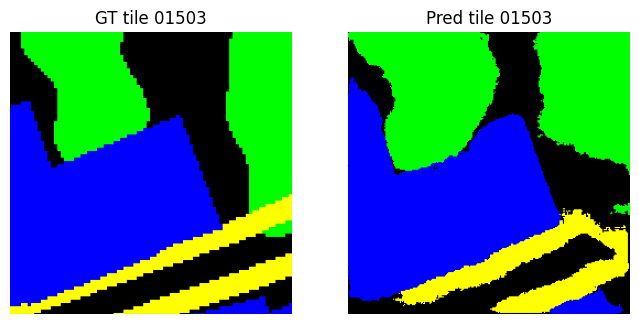

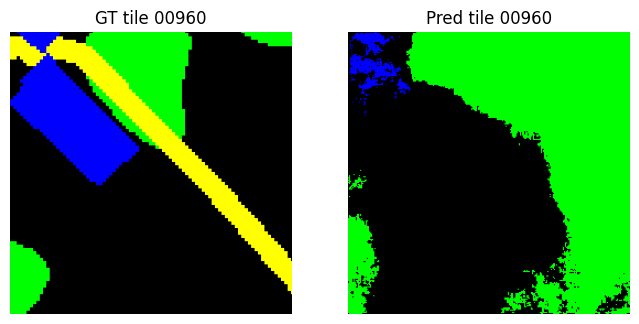

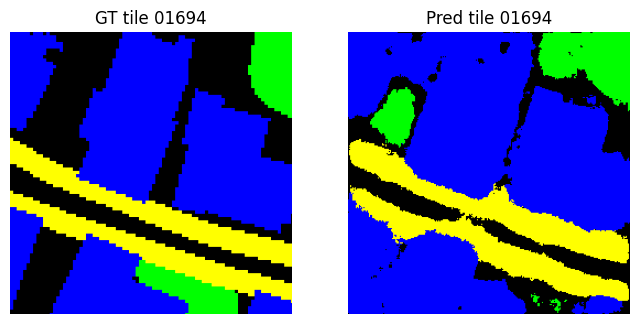

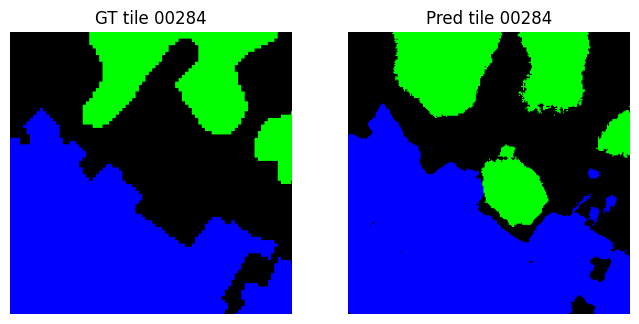

In [51]:
import numpy as np
from matplotlib import pyplot as plt

max_examples = 4   # ← número de ejemplos a mostrar

for i, (p, g, id_) in enumerate(zip(all_preds, all_gts, test_ids)):
    if i >= max_examples:
        break  # salimos del bucle después de 4

    p = p.astype(np.uint8)
    g = g.astype(np.uint8)

    pred_rgb = convert_to_color(p)
    gt_rgb   = convert_to_color(g)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(gt_rgb)
    plt.title(f"GT tile {int(id_):05d}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(pred_rgb)
    plt.title(f"Pred tile {int(id_):05d}")
    plt.axis("off")

    plt.show()


## 📚 Marco teórico breve y conceptos clave

Este notebook se centra en entrenar y evaluar un modelo de **segmentación semántica** sobre el dataset de **Yalí**, utilizando imágenes aéreas y máscaras de clases (background, buildings, roads, forest). A continuación resumo los conceptos teóricos básicos que sustentan lo que se hizo en el código.

---

### 🧠 Segmentación semántica en imágenes aéreas

La **segmentación semántica** consiste en asignar una etiqueta de clase a **cada píxel** de una imagen.  
En este caso, el objetivo es distinguir entre:

- `background` (fondo)
- `buildings` (edificaciones)
- `roads` (vías)
- `forest` (cobertura boscosa)

En imágenes aéreas o satelitales, este tipo de modelos se usa para tareas como:
- mapeo de uso/cobertura del suelo,
- detección de edificaciones,
- análisis de infraestructura vial,
- monitoreo ambiental.

---

### 🧩 Teselado (tiling) de la ortofoto y la máscara

Las ortofotos y sus máscaras suelen ser **muy grandes** (miles de píxeles por lado).  
En lugar de entrenar directamente con la imagen completa, se realiza un **teselado**:

- Se corta la ortofoto en pequeños parches (por ejemplo, 256×256 píxeles).
- Se corta la máscara en parches del mismo tamaño, perfectamente alineados.
- Cada par (imagen, máscara) se convierte en un ejemplo de entrenamiento.

Ventajas del tiling:

- Permite entrenar en GPUs con memoria limitada.
- Aumenta el número de ejemplos (más muestras para el modelo).
- Mantiene el contexto local suficiente para que la red aprenda patrones espaciales.

> 💡 En este notebook se generan tiles `yali_00001_img.tif`, `yali_00001_mask.tif`, etc., que luego se usan para entrenamiento y prueba.

---

### 🏗️ Redes convolucionales y arquitectura tipo SegNet

El modelo utilizado sigue la idea de arquitecturas **encoder–decoder** para segmentación, como **SegNet**:

- **Encoder**:  
  Extrae características de alto nivel a partir de la imagen original mediante capas convolucionales y operaciones de pooling (reduce la resolución pero captura patrones más abstractos).

- **Decoder**:  
  Reconstruye un mapa de clases a la resolución original, usando operaciones de upsampling y convoluciones para proyectar las características hacia el espacio de píxeles.

En muchos trabajos se usan pesos preentrenados de **VGG16** en el encoder para aprovechar conocimiento previo sobre imágenes naturales.  
En este experimento concreto con Yalí:

- El código incluye la lógica para cargar pesos de VGG16,
- pero **no se utilizaron finalmente** por incompatibilidades con la arquitectura y la configuración del modelo,
- por lo que el entrenamiento se realiza esencialmente desde cero sobre los tiles de Yalí.

---

### 📏 Métricas de evaluación

Para cuantificar el desempeño del modelo se utilizan varias métricas estándar en segmentación semántica:

- **Overall Accuracy (OA)**  
  Proporción total de píxeles correctamente clasificados.  
  > Mide qué porcentaje del mapa completo está bien etiquetado.

- **IoU por clase (Intersection over Union)**  
  Para cada clase, compara el área de intersección entre predicción y verdad terreno con el área de unión.  
  > Indica qué tan bien se solapan las regiones predichas con las reales.  
  El **mIoU** es el promedio de IoU entre todas las clases.

- **Precision / Recall / F1-score por clase**  
  - *Precision*: de todo lo que el modelo marcó como una clase, qué proporción era correcto.  
  - *Recall*: de todo lo que en realidad era de esa clase, cuánto logró recuperar el modelo.  
  - *F1*: media armónica entre precision y recall, resume ambas en un solo valor.

- **Kappa de Cohen**  
  Mide el nivel de acuerdo entre la predicción del modelo y la verdad terreno, corrigiendo el efecto del azar.  
  > Valores cercanos a 1 indican un acuerdo fuerte; valores cercanos a 0 indican un acuerdo cercano al azar.

Estas métricas se calculan agrupando todos los píxeles de todos los tiles del conjunto de prueba, a partir de las matrices de confusión.

---

### 🖼️ Ideas de imágenes para documentar el notebook

Si se desea enriquecer el notebook con figuras, algunas ideas útiles serían:

- Un esquema simple de una arquitectura **encoder–decoder** (por ejemplo, bloques de encoder a la izquierda y decoder a la derecha).
- Un ejemplo visual de:
  - un tile de la ortofoto, y
  - su máscara de clases correspondiente.
- Una representación sencilla de la **matriz de confusión** (por ejemplo, como mapa de calor) para ilustrar cómo se distribuyen los aciertos y errores entre clases.

---

### 🔎 Referencias sugeridas (lectura opcional)

- Badrinarayanan, V., Kendall, A., & Cipolla, R.  
  *SegNet: A Deep Convolutional Encoder-Decoder Architecture for Image Segmentation*. IEEE TPAMI, 2017.
- Revisión general de deep learning para imágenes de Teledetección / Geomática (cualquier survey reciente sobre “deep learning for remote sensing semantic segmentation” puede complementar el contexto de este notebook).

### 📎 Referencia del notebook original (SegNet + ISPRS)

El flujo de trabajo de este notebook se basa y adapta el código publicado por **Nicolas Audebert** y colaboradores en el repositorio:

- DeepNetsForEO – *Deep networks for Earth Observation* (SegNet sobre ISPRS Vaihingen y Potsdam):  
  GitHub: https://github.com/nshaud/DeepNetsForEO

En particular, parto del cuaderno:

- `SegNet_PyTorch_v2.ipynb`, donde se entrena una arquitectura tipo **SegNet** para la segmentación semántica de las ciudades de Vaihingen y Potsdam (ISPRS 2D Semantic Labeling).

La referencia recomendada por los autores para citar el trabajo original es:

> N. Audebert, B. Le Saux, and S. Lefèvre, “Beyond RGB: Very High Resolution Urban Remote Sensing With Multimodal Deep Networks,” *ISPRS Journal of Photogrammetry and Remote Sensing*, 2017.  

En este notebook, adapto ese flujo de trabajo a mi propio caso de estudio en **Yalí**, reemplazando las imágenes ISPRS por ortofotos y máscaras generadas específicamente para esta zona de Colombia.
